In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
sns.set(style="whitegrid", font="STIXGeneral", context="talk", palette="colorblind")
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [23]:
# def visualize(dataset_name, generators_sel, metrics):
#     current_path = os.getcwd()  # Get current working directory
#     parent_path = os.path.dirname(current_path)
#     res_dir = parent_path +  "/dataset/" + dataset_name
#     list_n_samples_control = [(1/3), (2/3), 1.0]
#     #### SYNTHCITY METRICS
#     num_metrics = len(metrics)
#     n_learners = len(generators_sel)
#     fig, axs = plt.subplots(len(list_n_samples_control), num_metrics, figsize=(4 * num_metrics * n_learners, 6 * len(list_n_samples_control)))

#     if num_metrics == 1:
#         axs = [axs]  # ensure axs is iterable

#     for i in range(len(list_n_samples_control)):
#         results_ext = pd.read_csv(res_dir + '/metric_results/traincontrol_aug_Ncontrol{}%3_general_scores_df_ext.csv'.format((i+1)))
#         for j, ax in enumerate(axs[i]):
#             # Format axis spines
#             metric_name, opt = metrics[j]
#             for spine in ax.spines.values():
#                 spine.set_linewidth(2)
#                 spine.set_edgecolor('black')

#             sns.boxplot(data=results_ext, x='generator', y=metric_name, ax=ax,
#                         linewidth = 3, saturation = 1, palette = 'colorblind', 
#                         width = 1, gap = 0.15, whis = 0.8, linecolor="Black")
#             ax.set_xlabel('')
#             ax.set_ylabel(metric_name, fontsize=20, fontweight="semibold")
#             ax.set_title("Aug level {}%3".format(i+1), fontsize=30, fontweight="semibold")
#             ax.tick_params(axis='x', labelsize=18)
#             ax.tick_params(axis='y', labelsize=18)
#             if opt == "max":
#                 ax.legend(title='Maximize \u2191', title_fontsize=15)
#             else:
#                 ax.legend(title='Minimize \u2193', title_fontsize=15)
#     plt.tight_layout(pad=3)
#     plt.show()

def visualize(dataset_name, generators_sel, metrics):
    current_path = os.getcwd()  # Get current working directory
    parent_path = os.path.dirname(current_path)
    res_dir = parent_path +  "/dataset/" + dataset_name
    list_n_samples_control = [(1/3), (2/3), 1.0]
    #### SYNTHCITY METRICS
    num_metrics = len(metrics)
    n_learners = len(generators_sel)
    fig, axs = plt.subplots(len(list_n_samples_control), num_metrics, figsize=(4 * num_metrics * n_learners, 8 * len(list_n_samples_control)))

    if num_metrics == 1:
        axs = [axs]  # ensure axs is iterable

    for i in range(len(list_n_samples_control)):
        results = pd.read_csv(res_dir + '/metric_results_DetectXGB/traincontrol_aug_Ncontrol{}%3_general_scores_df.csv'.format((i+1)))
        results_ext = pd.read_csv(res_dir + '/metric_results_DetectXGB/traincontrol_aug_Ncontrol{}%3_general_scores_df_ext.csv'.format((i+1)))
        results_ext['generator'] = results_ext['generator'] + '_cond'
        results = pd.concat([results, results_ext], ignore_index=True)
        for j, ax in enumerate(axs[i]):
            # Format axis spines
            metric_name, opt = metrics[j]
            for spine in ax.spines.values():
                spine.set_linewidth(2)
                spine.set_edgecolor('black')

            sns.boxplot(data=results, x='generator', y=metric_name, ax=ax,
                        linewidth = 3, saturation = 1, palette = 'colorblind', 
                        width = 1, gap = 0.15, whis = 0.8, linecolor="Black")
            ax.set_xlabel('')
            ax.set_ylabel(metric_name, fontsize=20, fontweight="semibold")
            ax.set_title("Aug level {}%3".format(i+1), fontsize=30, fontweight="semibold")
            ax.tick_params(axis='x', labelsize=18)
            ax.tick_params(axis='y', labelsize=18)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=10, ha='right', rotation_mode='anchor')
            if opt == "max":
                ax.legend(title='Maximize ↑', title_fontsize=15)
            else:
                ax.legend(title='Minimize ↓', title_fontsize=15)
    plt.tight_layout(pad=3)
    plt.show()

In [24]:
generators_sel = ["HI-VAE_weibull", "HI-VAE_piecewise", 
                  "Surv-GAN", "Surv-VAE", 
                  "HI-VAE_weibull_prior", 
                  "HI-VAE_piecewise_prior"]

# ACTG320

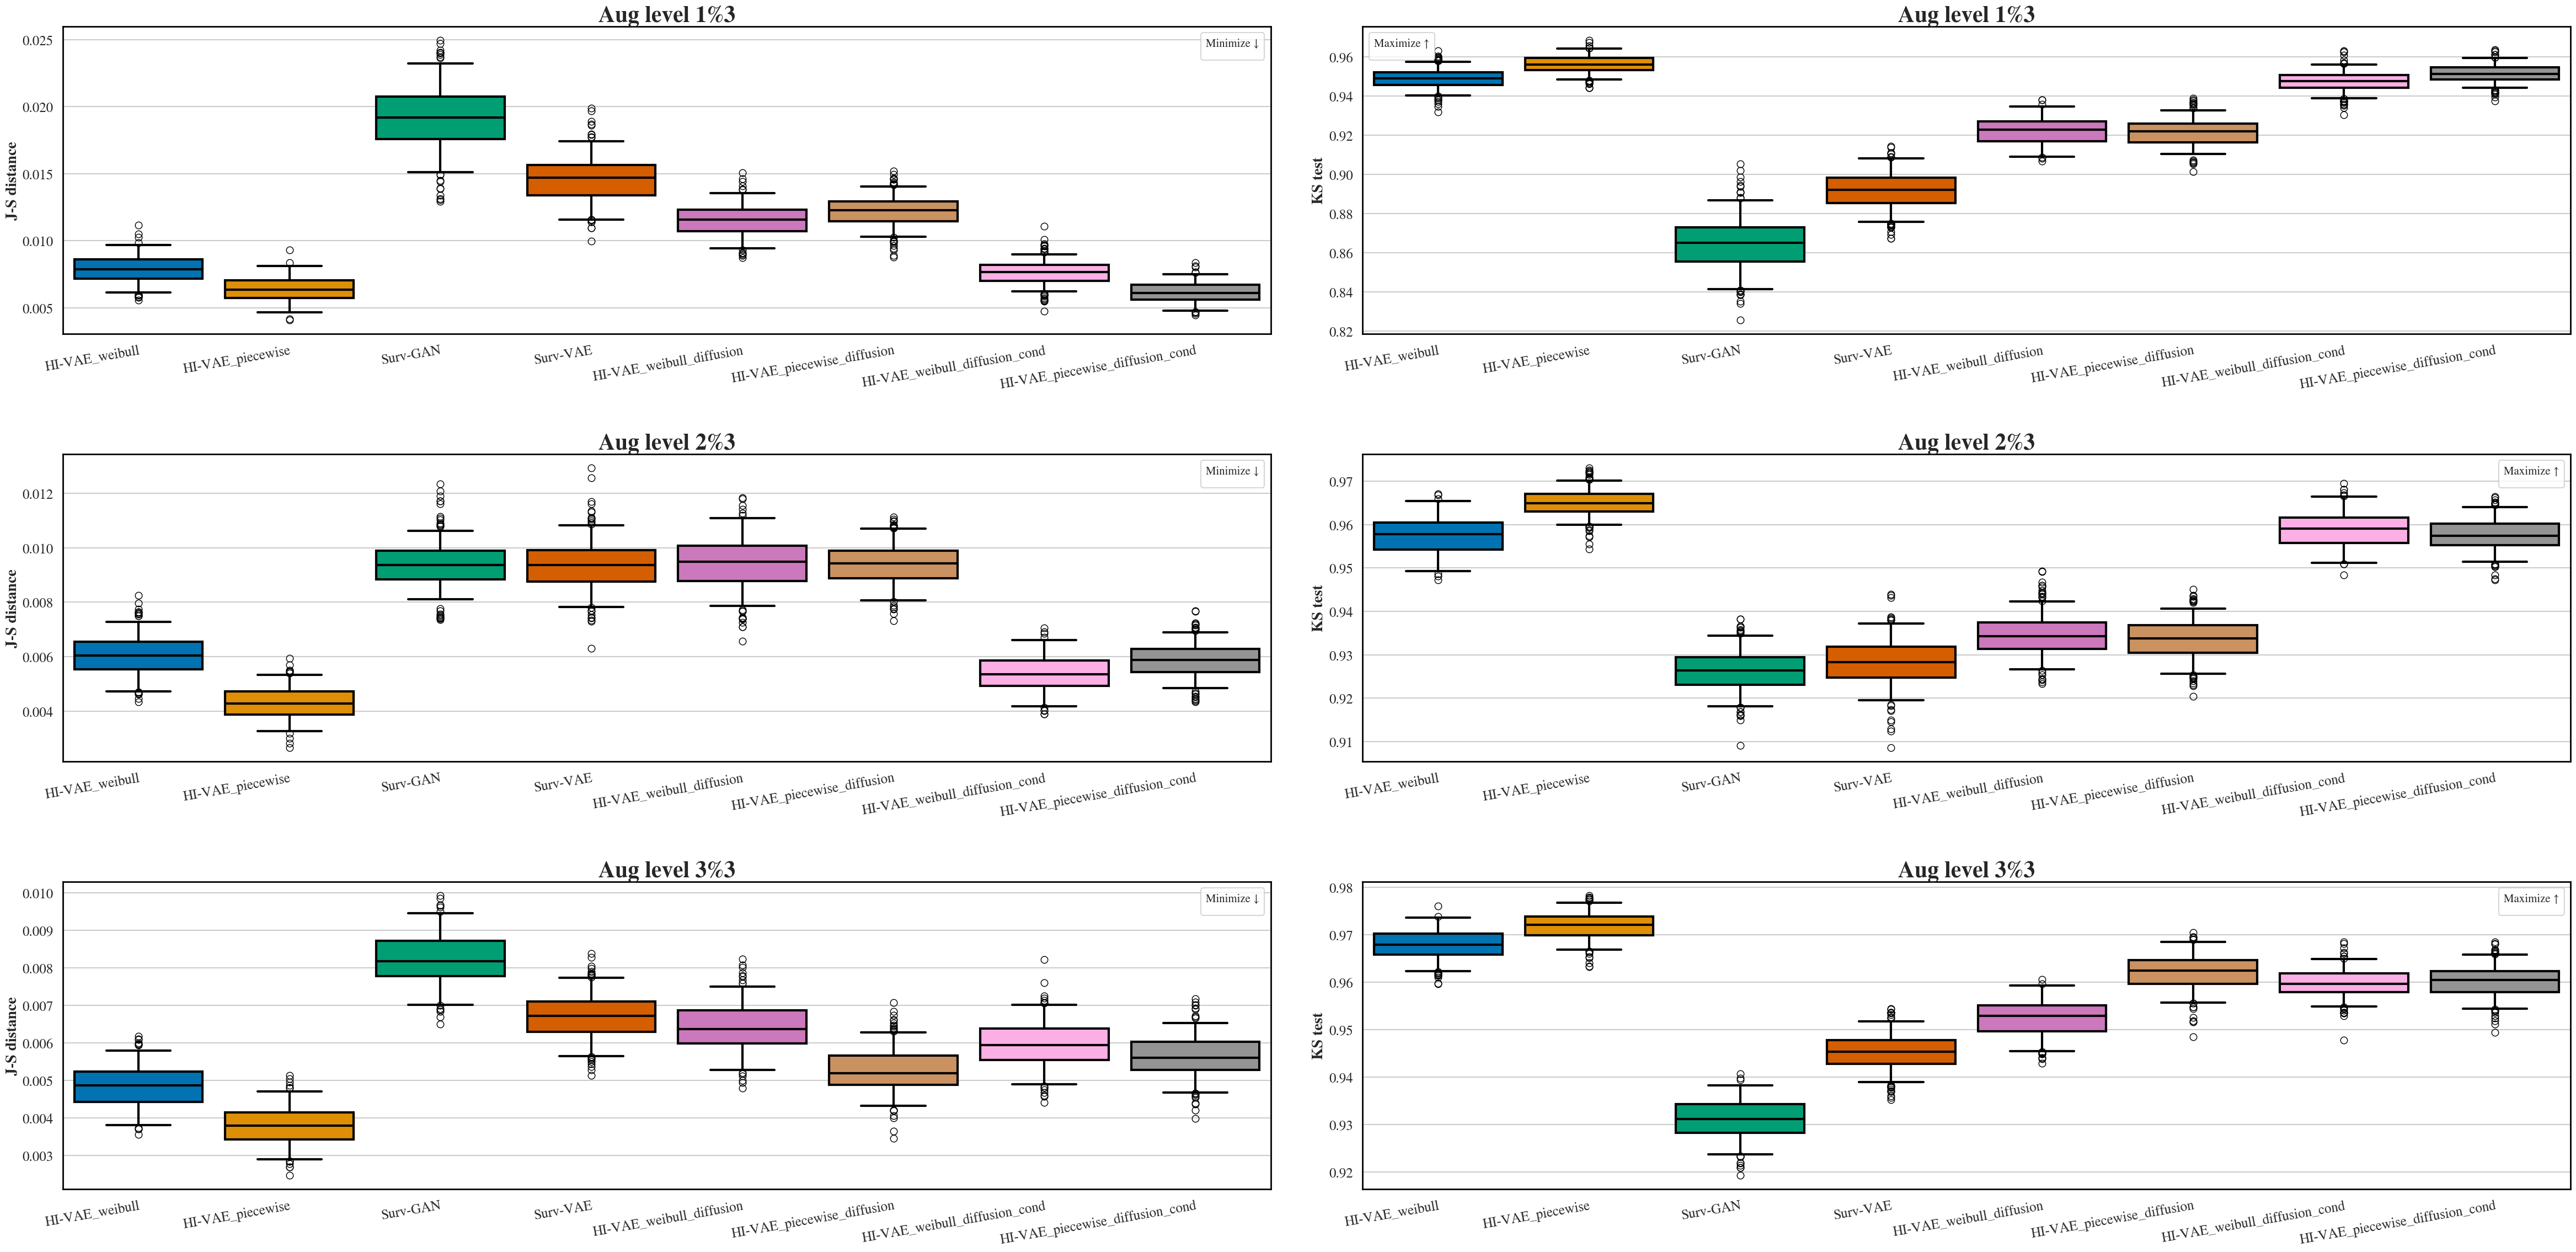

In [25]:
visualize("ACTG320", generators_sel, metrics=[['J-S distance', "min"], ['KS test', "max"]])

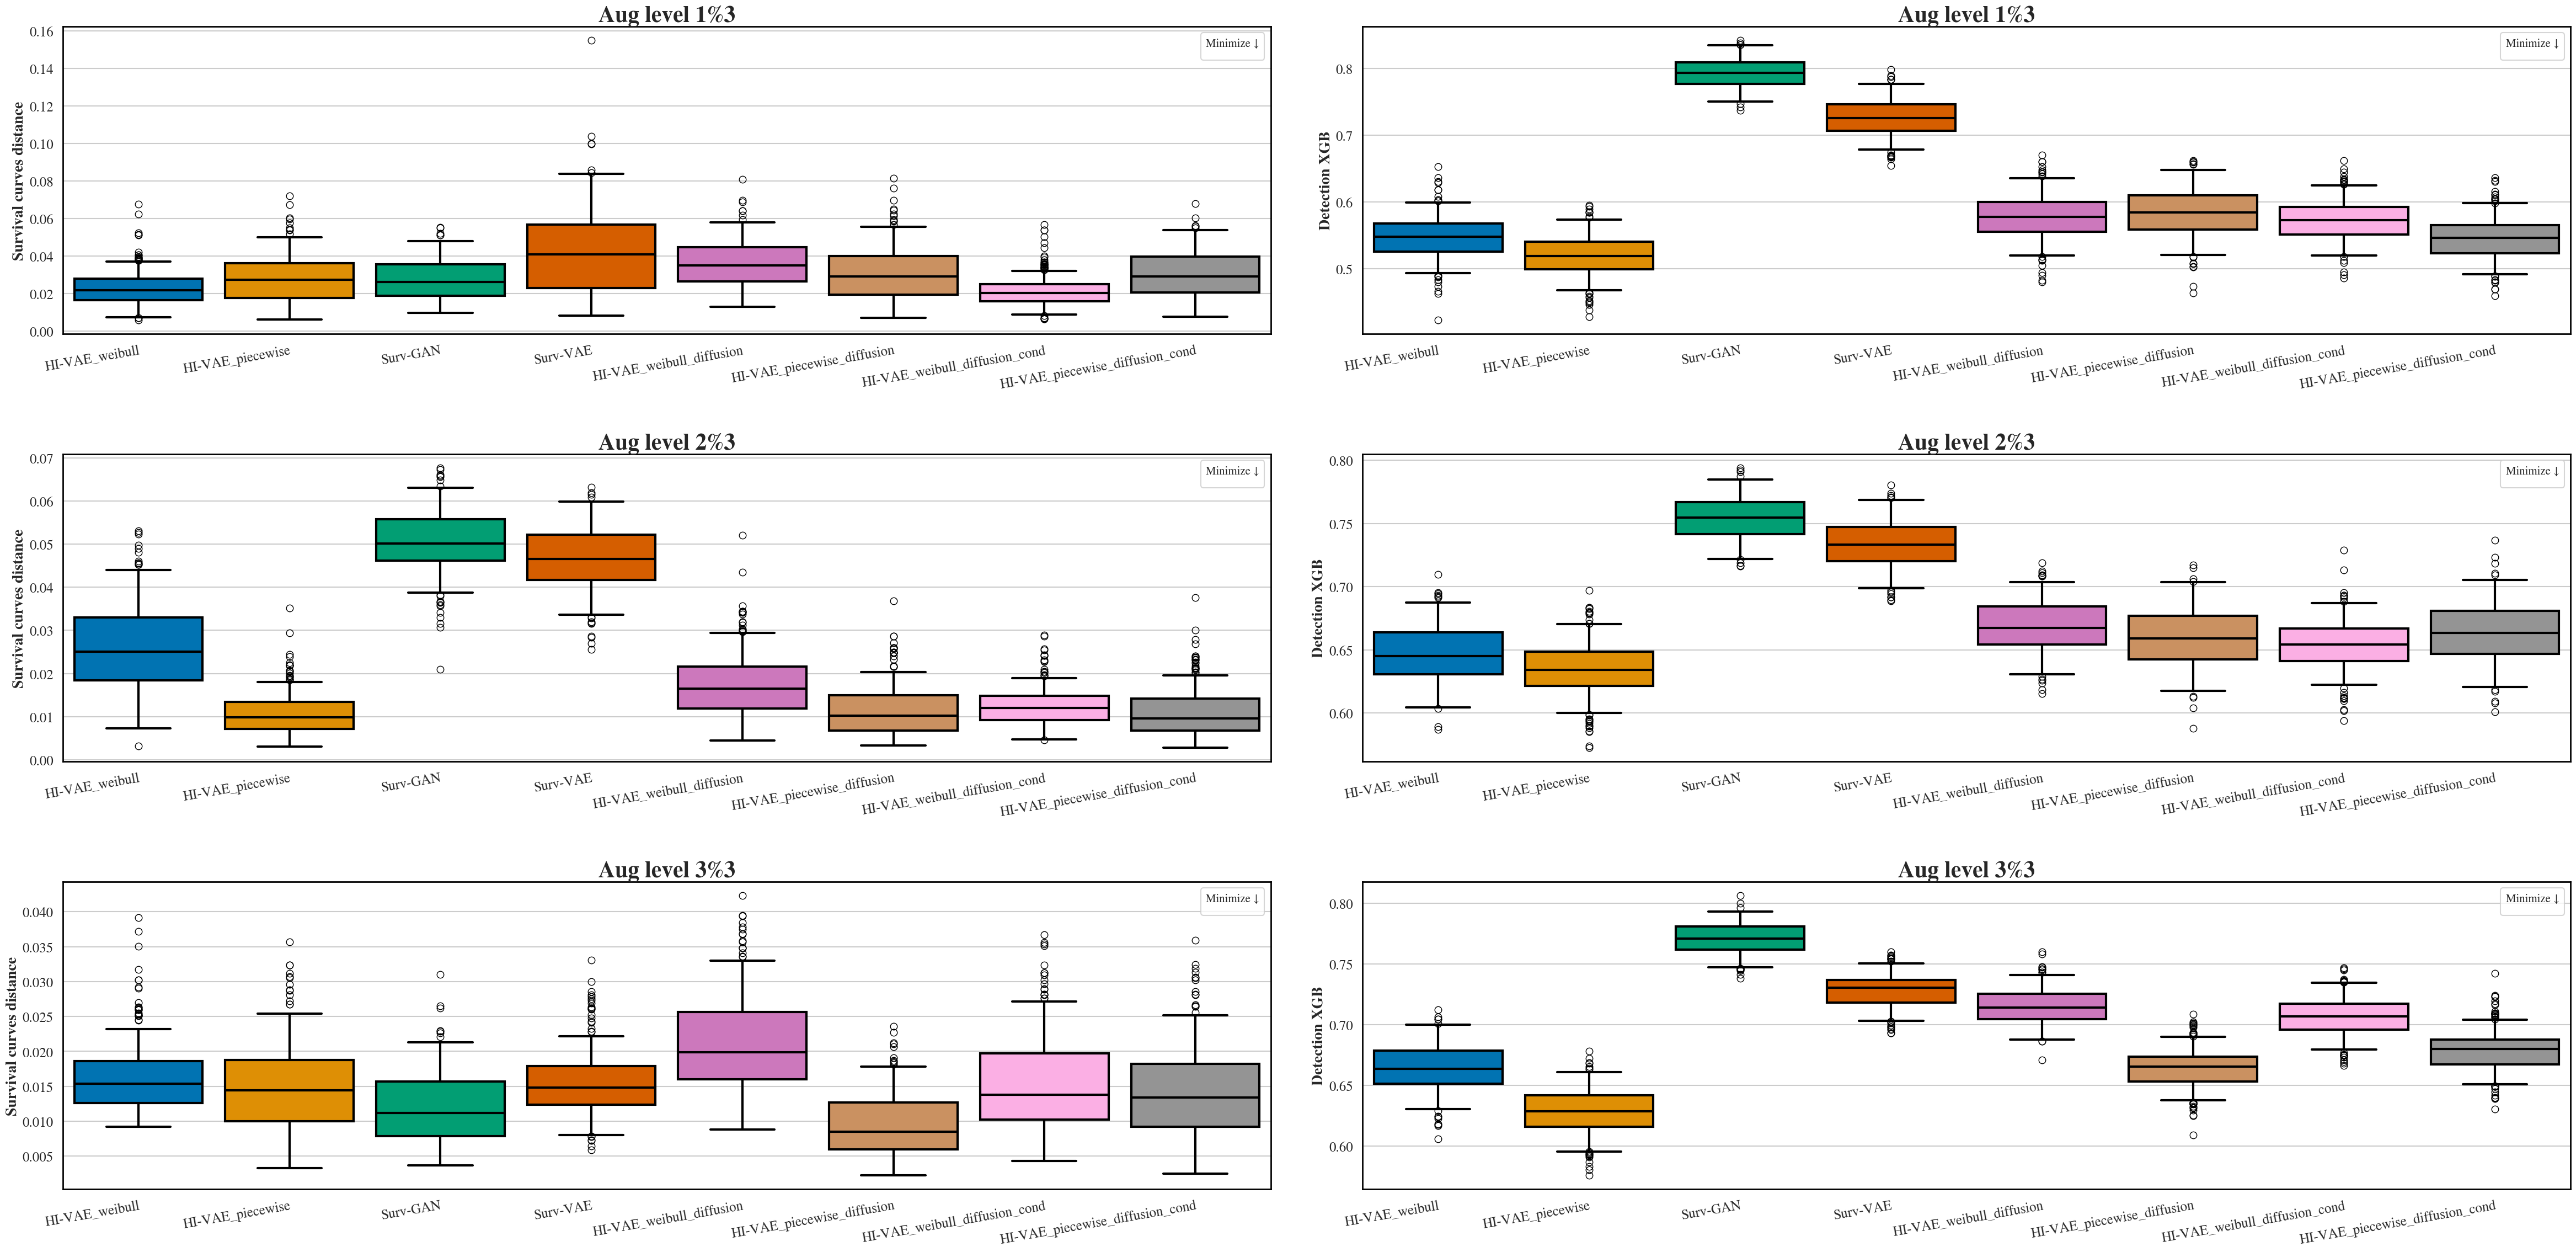

In [26]:
visualize("ACTG320", generators_sel, metrics=[['Survival curves distance', "min"], ['Detection XGB', "min"]])

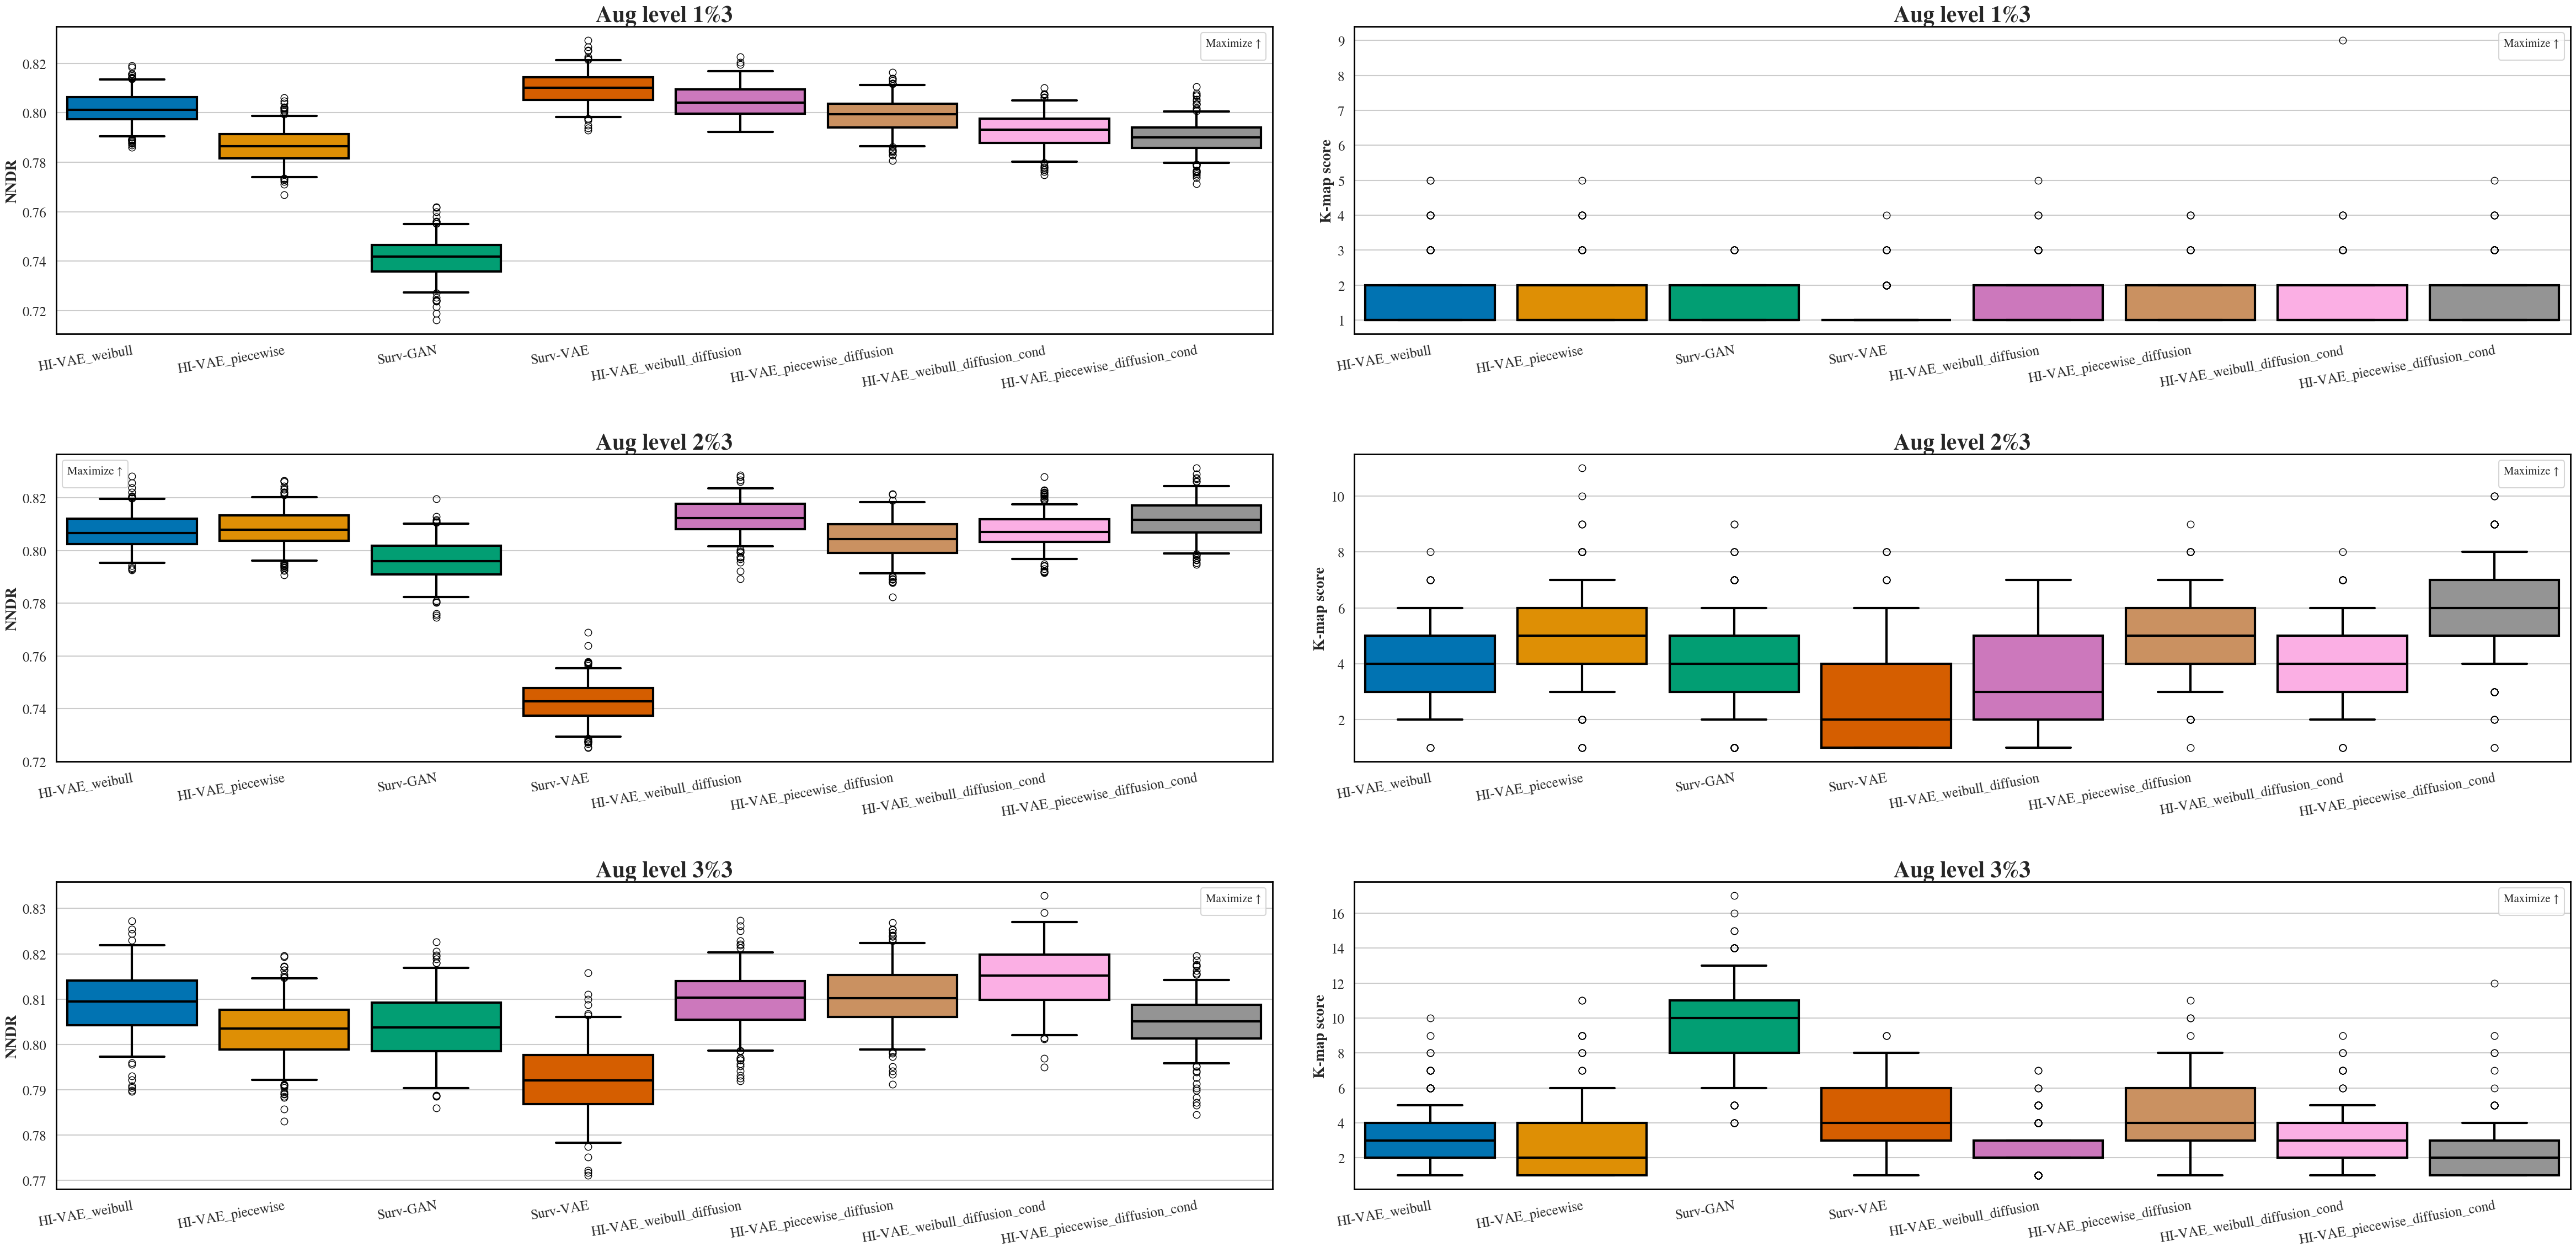

In [27]:
visualize("ACTG320", generators_sel, metrics=[['NNDR', "max"], ['K-map score', "max"]])

# NCT00119613

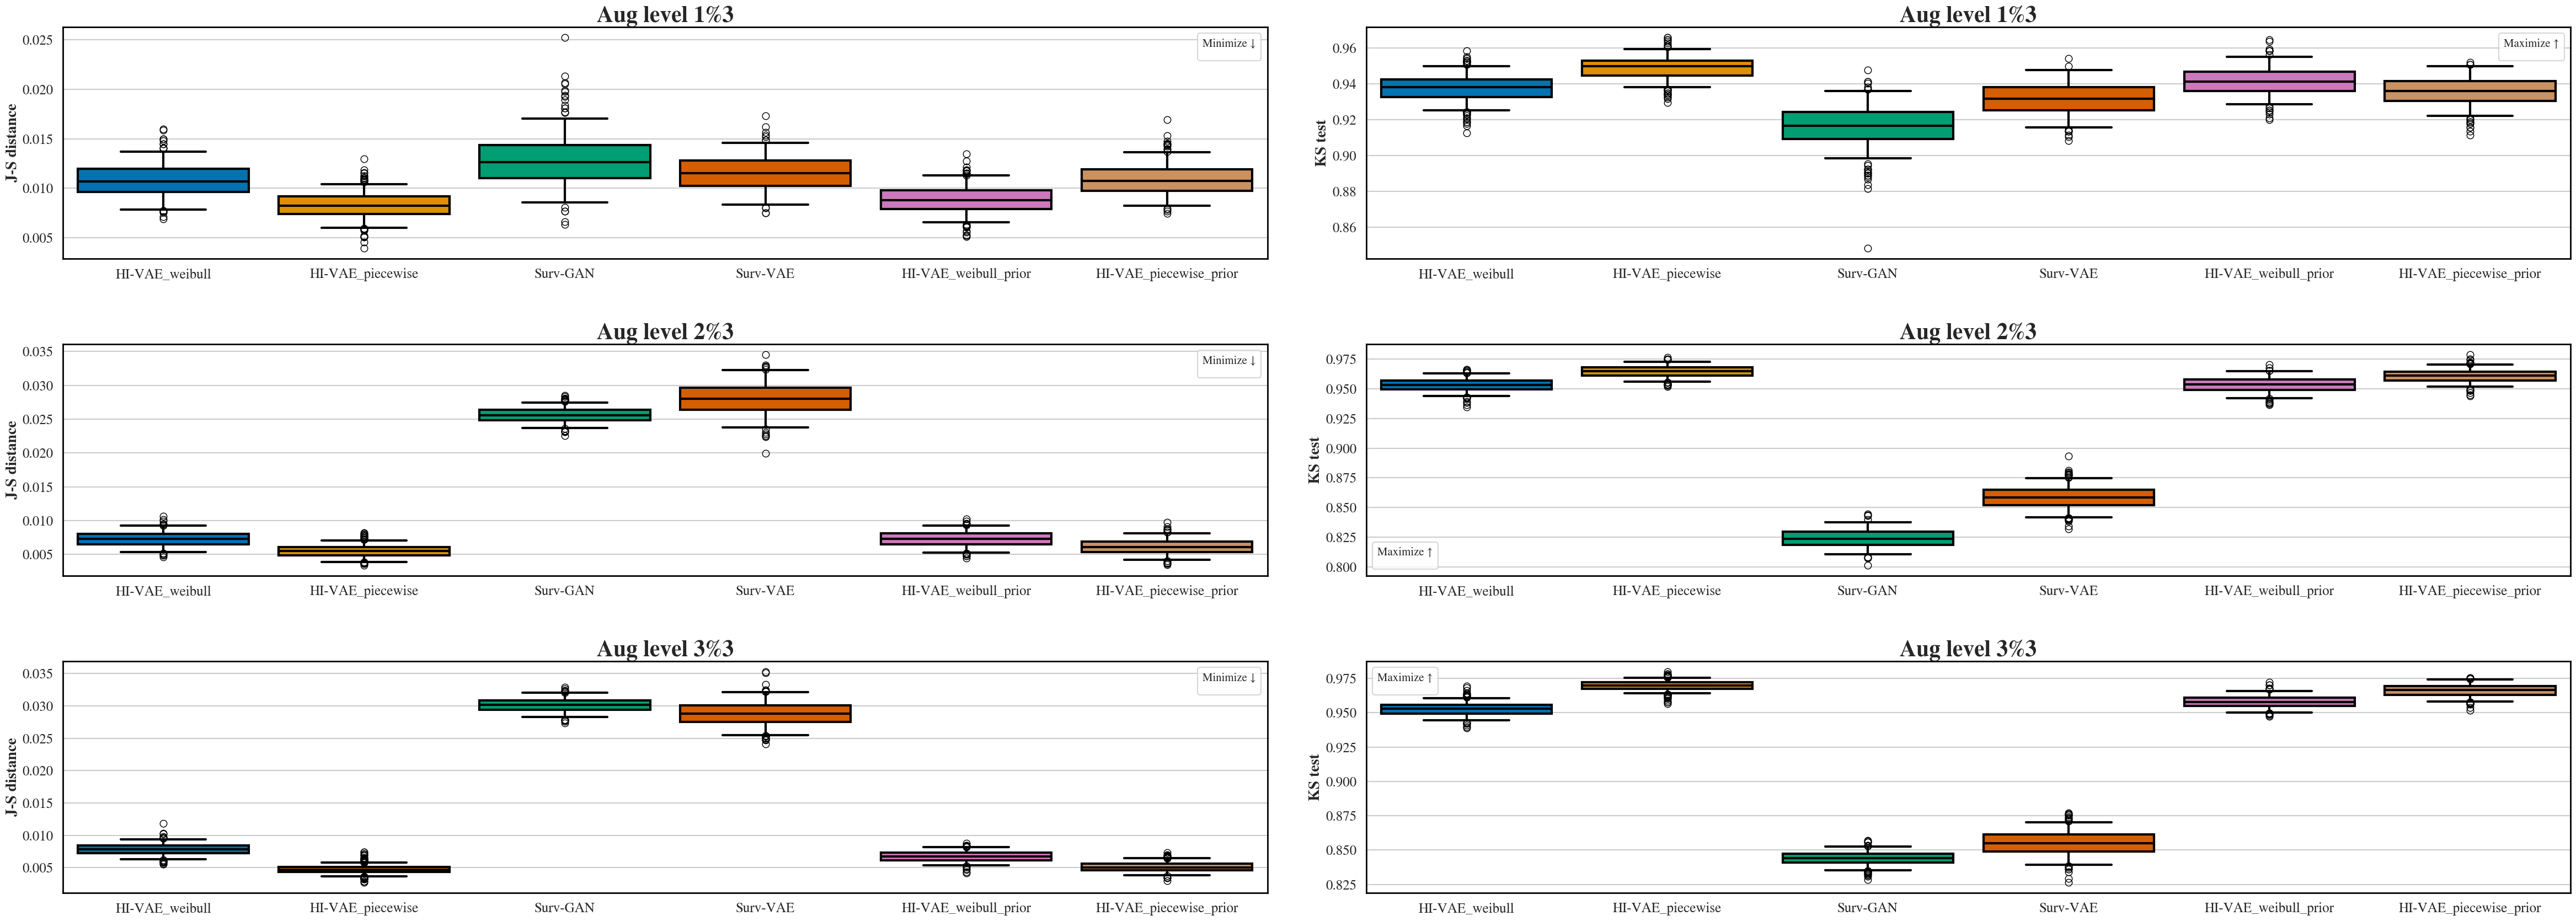

In [7]:
visualize("NCT00119613", generators_sel, metrics=[['J-S distance', "min"], ['KS test', "max"]])

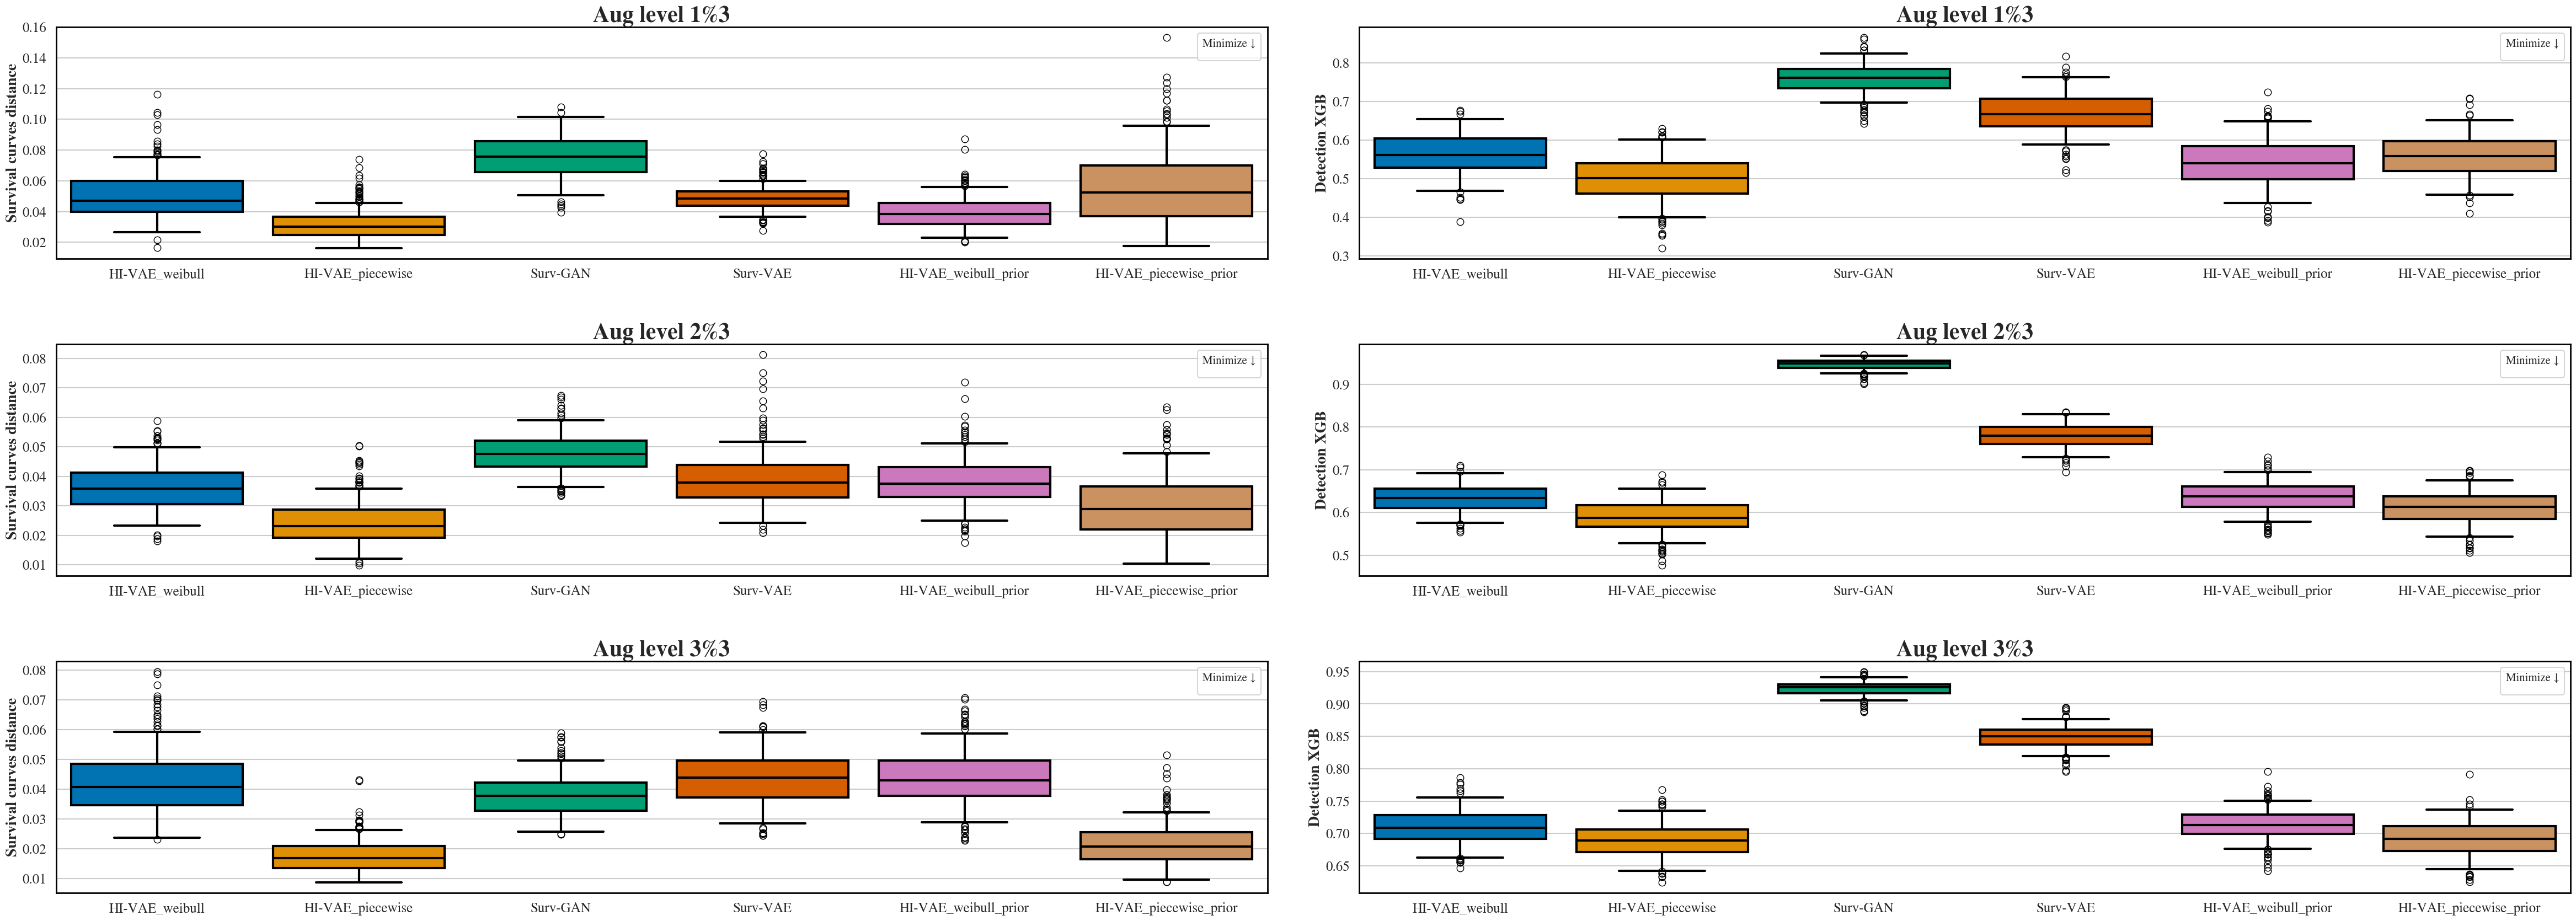

In [8]:
visualize("NCT00119613", generators_sel, metrics=[['Survival curves distance', "min"], ['Detection XGB', "min"]])

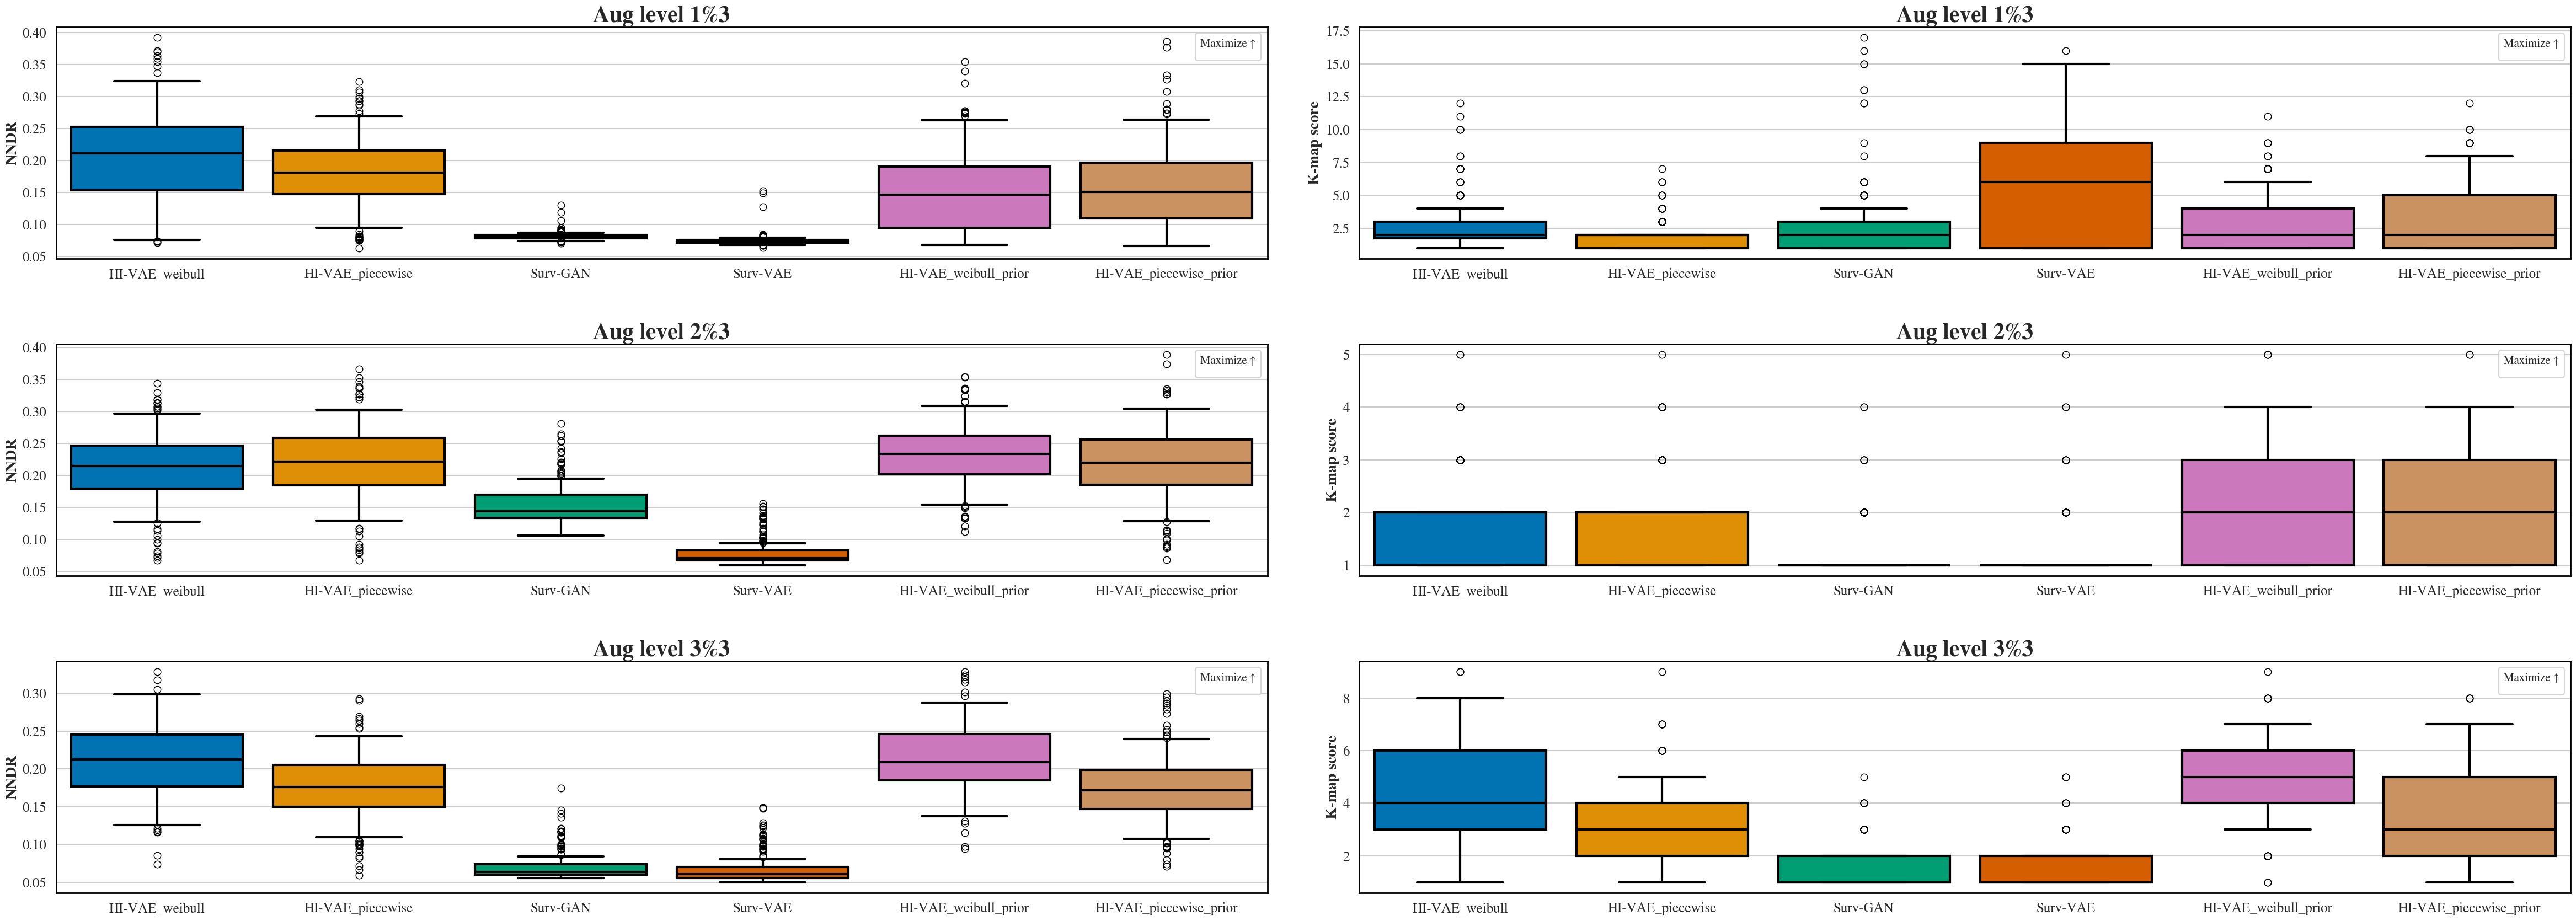

In [9]:
visualize("NCT00119613", generators_sel, metrics=[['NNDR', "max"], ['K-map score', "max"]])

# NCT00113763

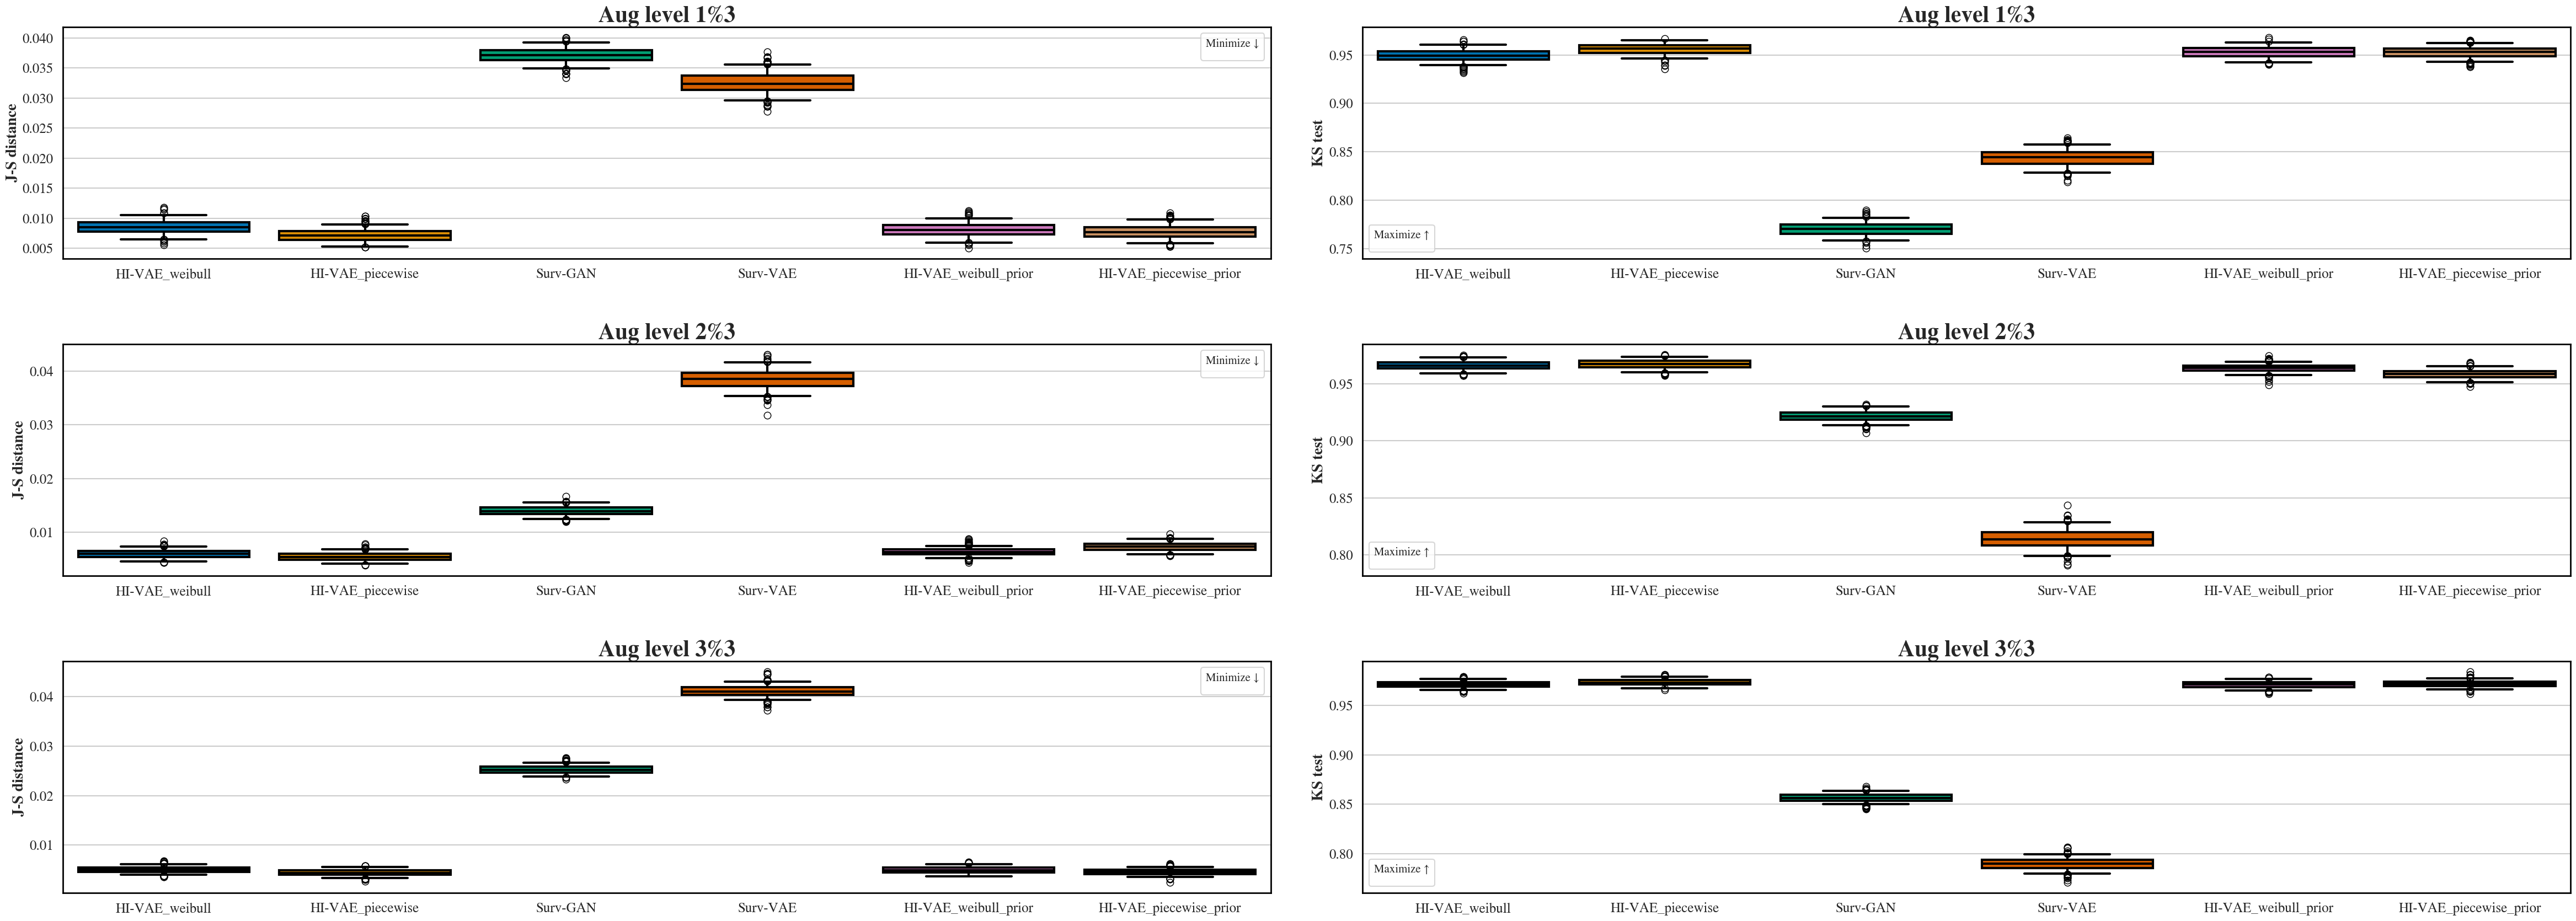

In [10]:
visualize("NCT00113763", generators_sel, metrics=[['J-S distance', "min"], ['KS test', "max"]])

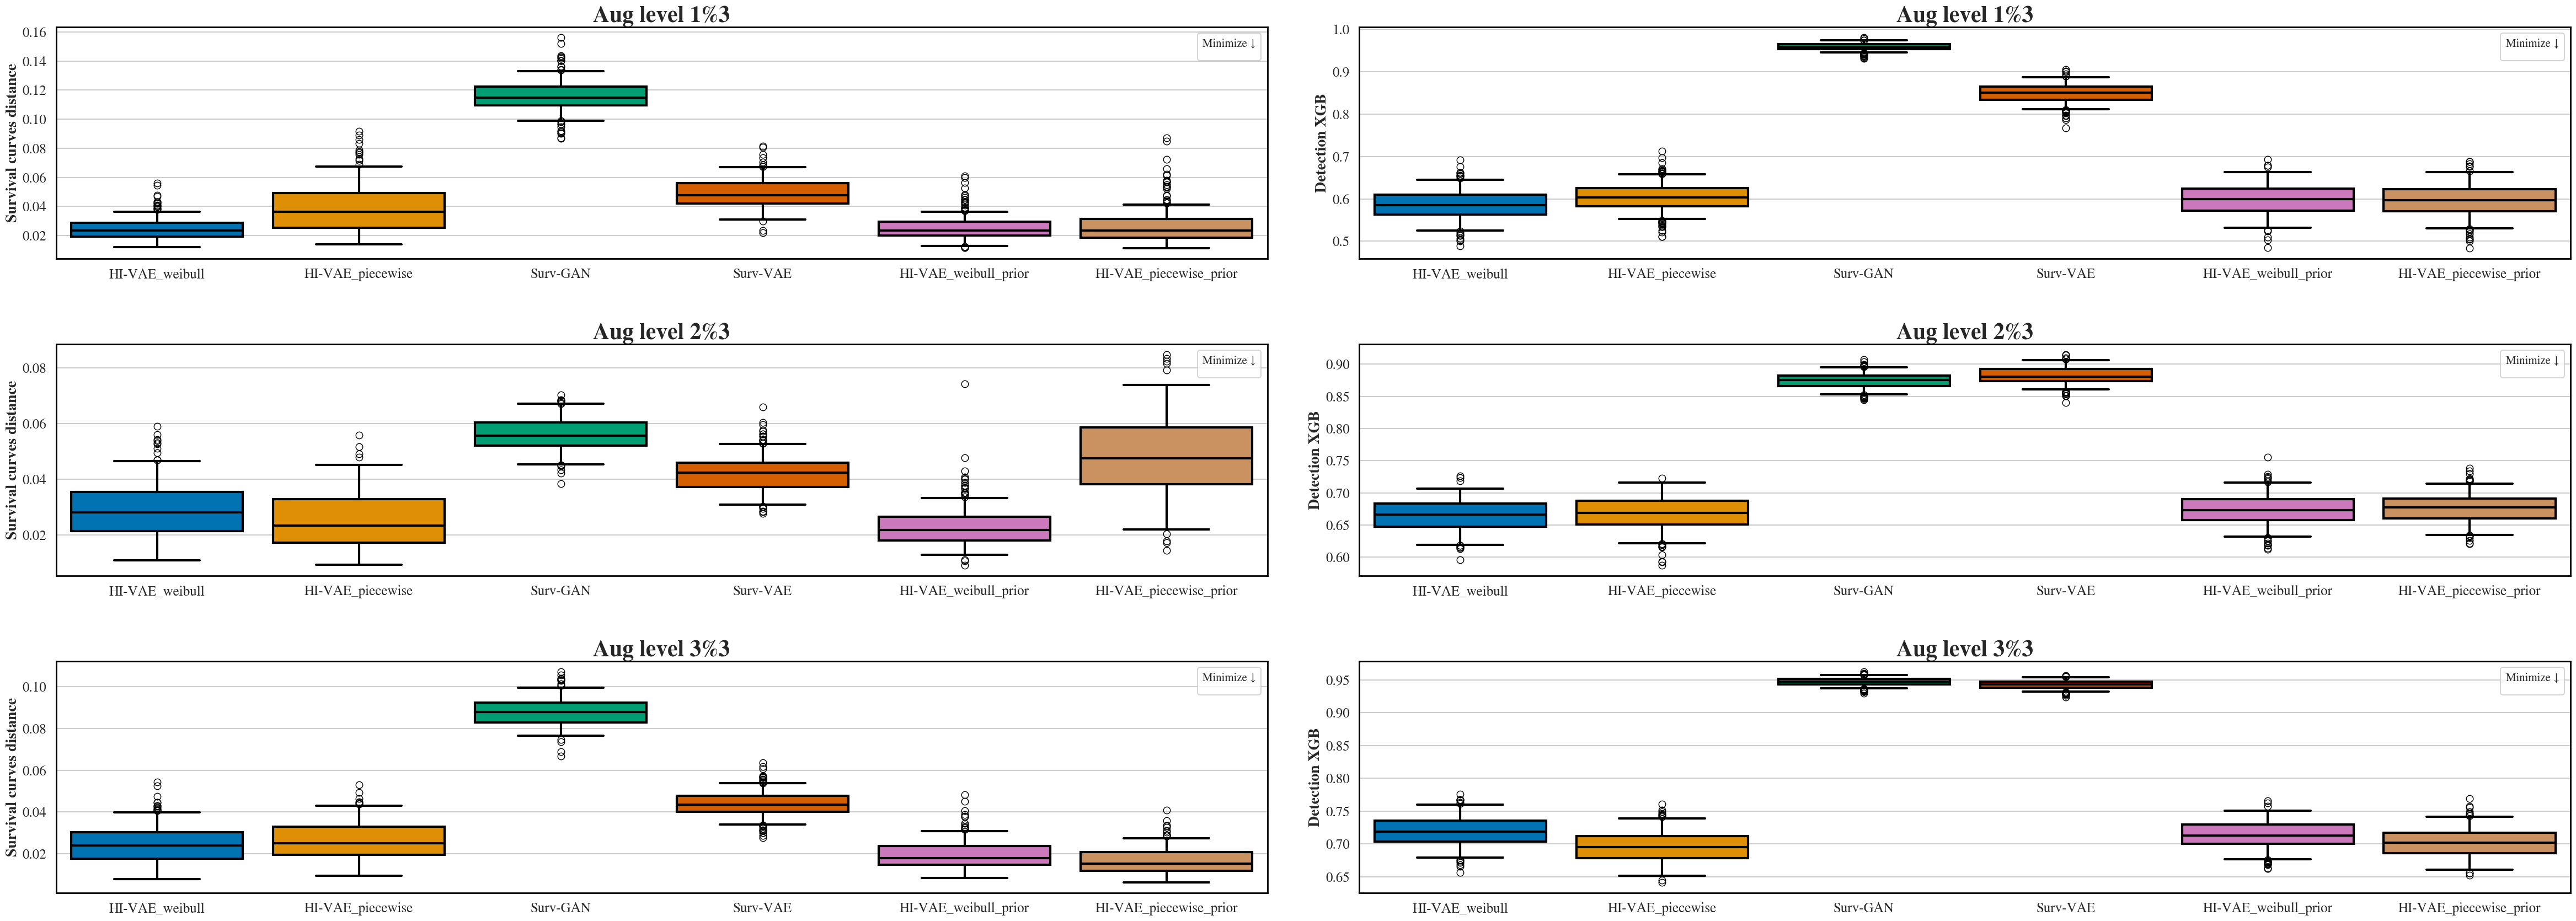

In [11]:
visualize("NCT00113763", generators_sel, metrics=[['Survival curves distance', "min"], ['Detection XGB', "min"]])

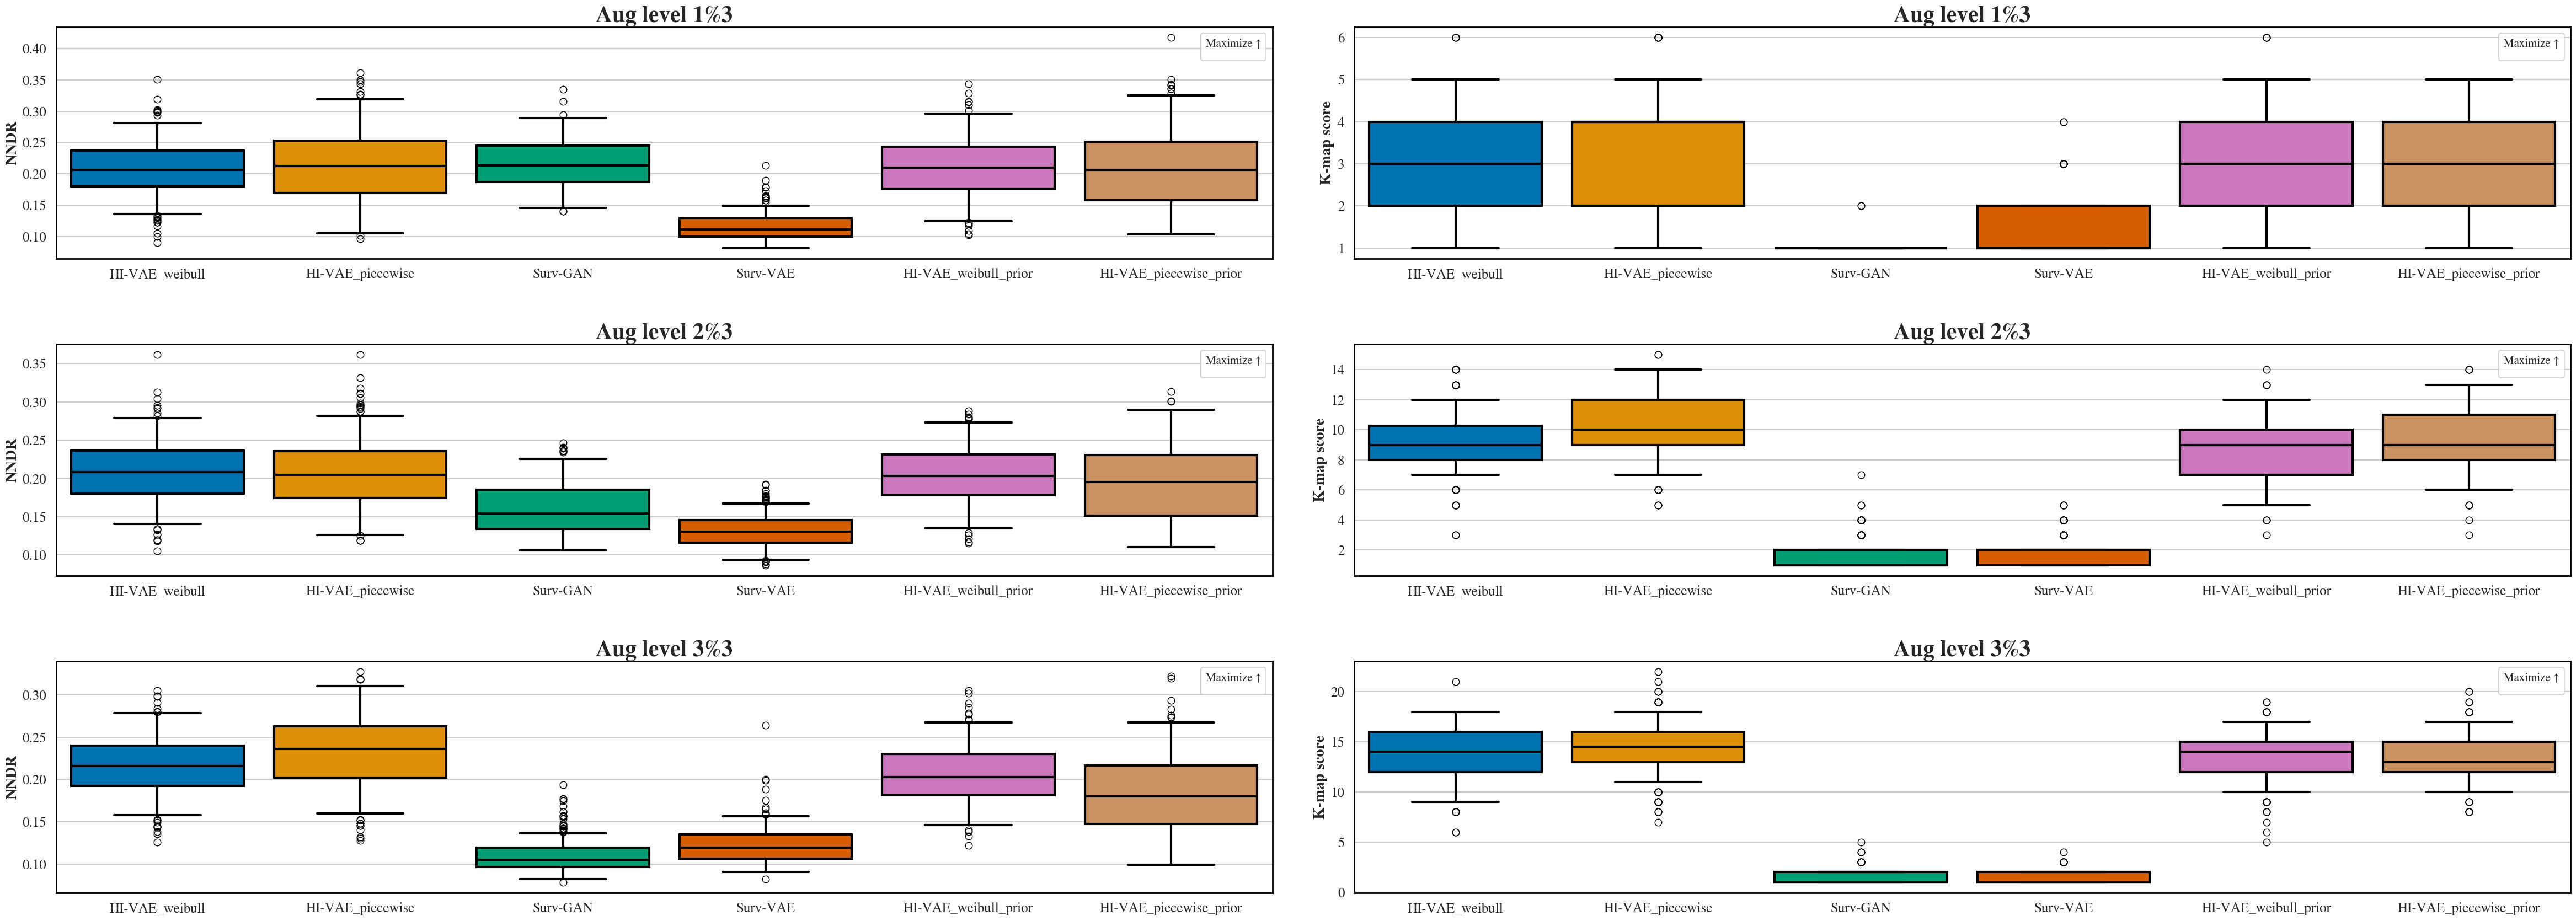

In [12]:
visualize("NCT00113763", generators_sel, metrics=[['NNDR', "max"], ['K-map score', "max"]])

# NCT00339183

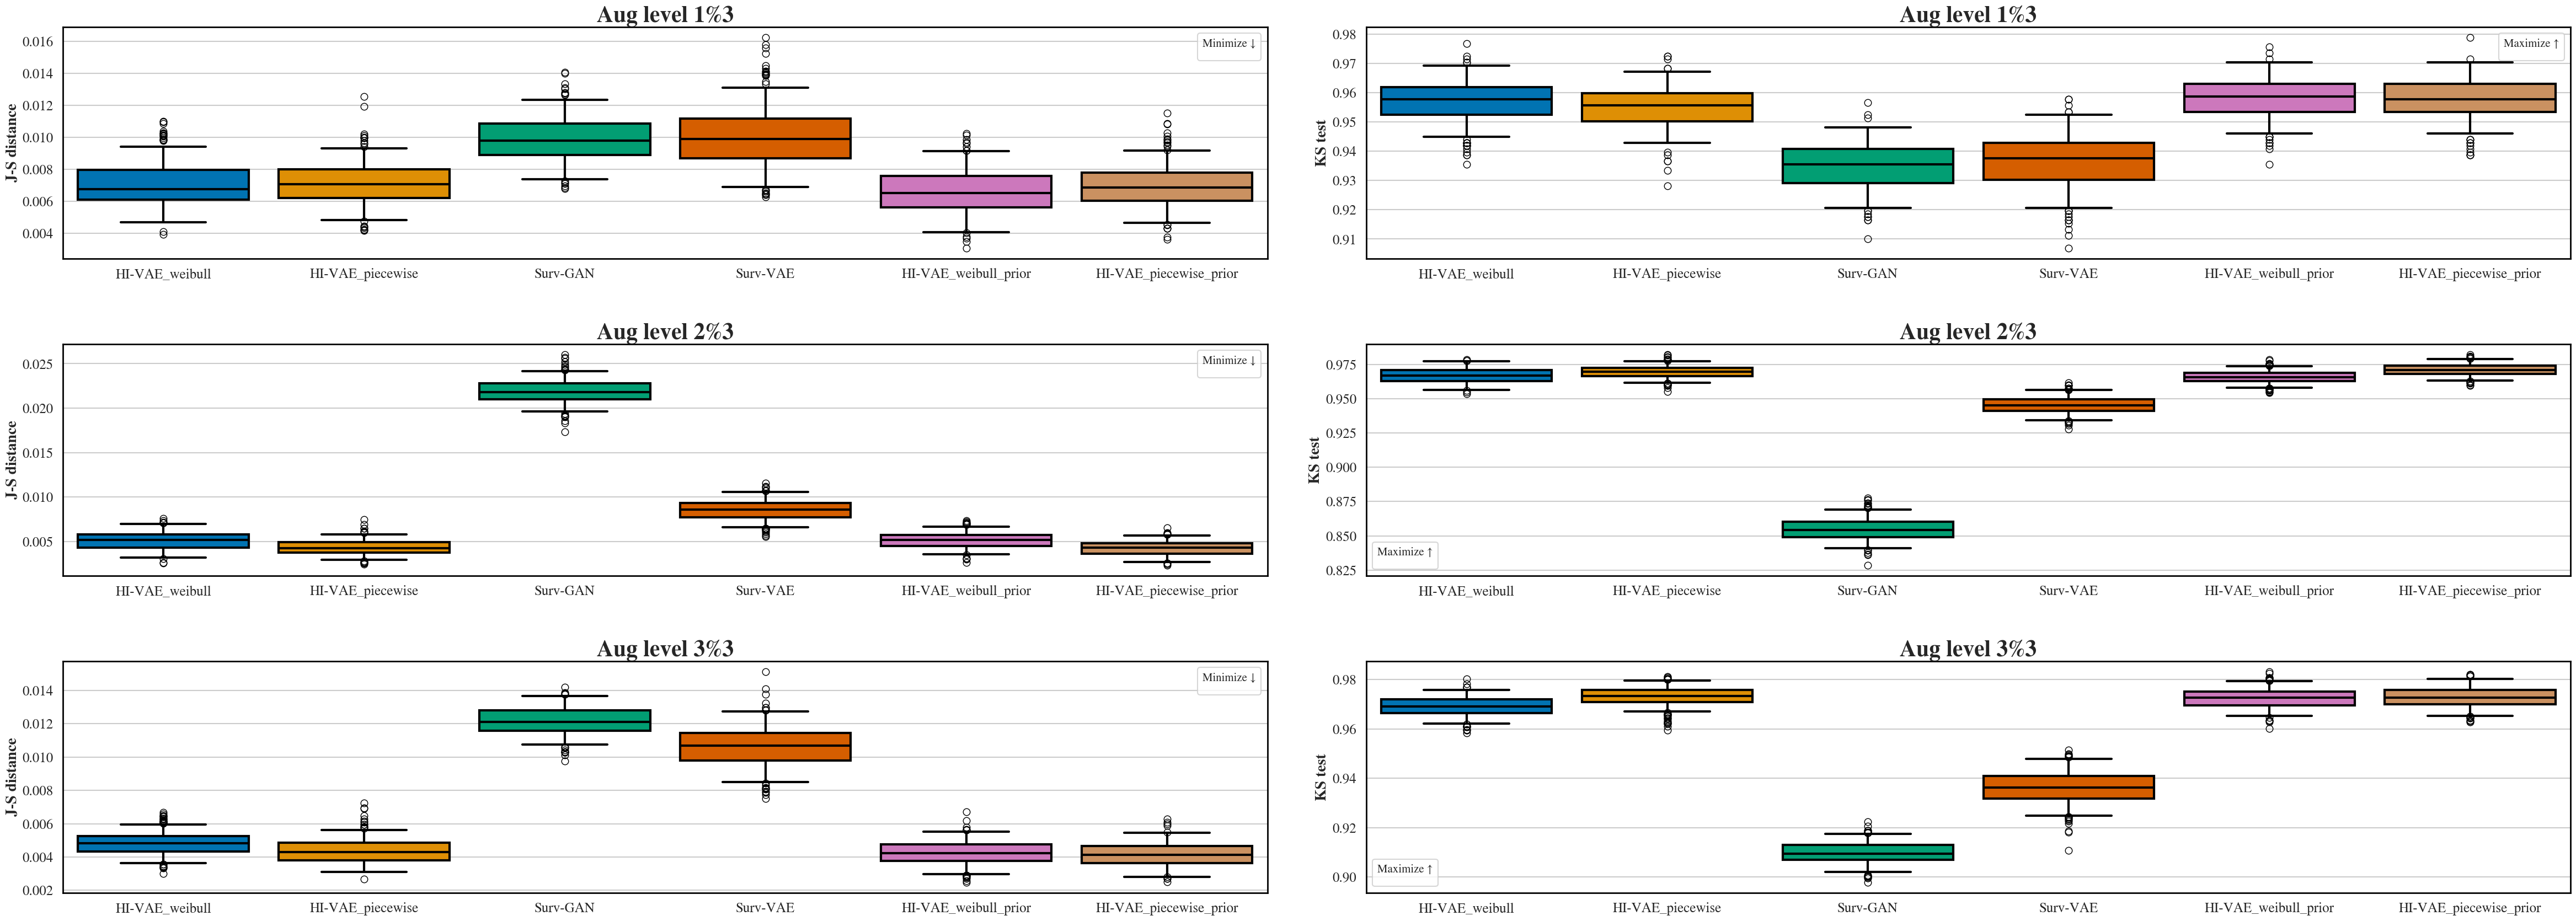

In [13]:
visualize("NCT00339183", generators_sel, metrics=[['J-S distance', "min"], ['KS test', "max"]])

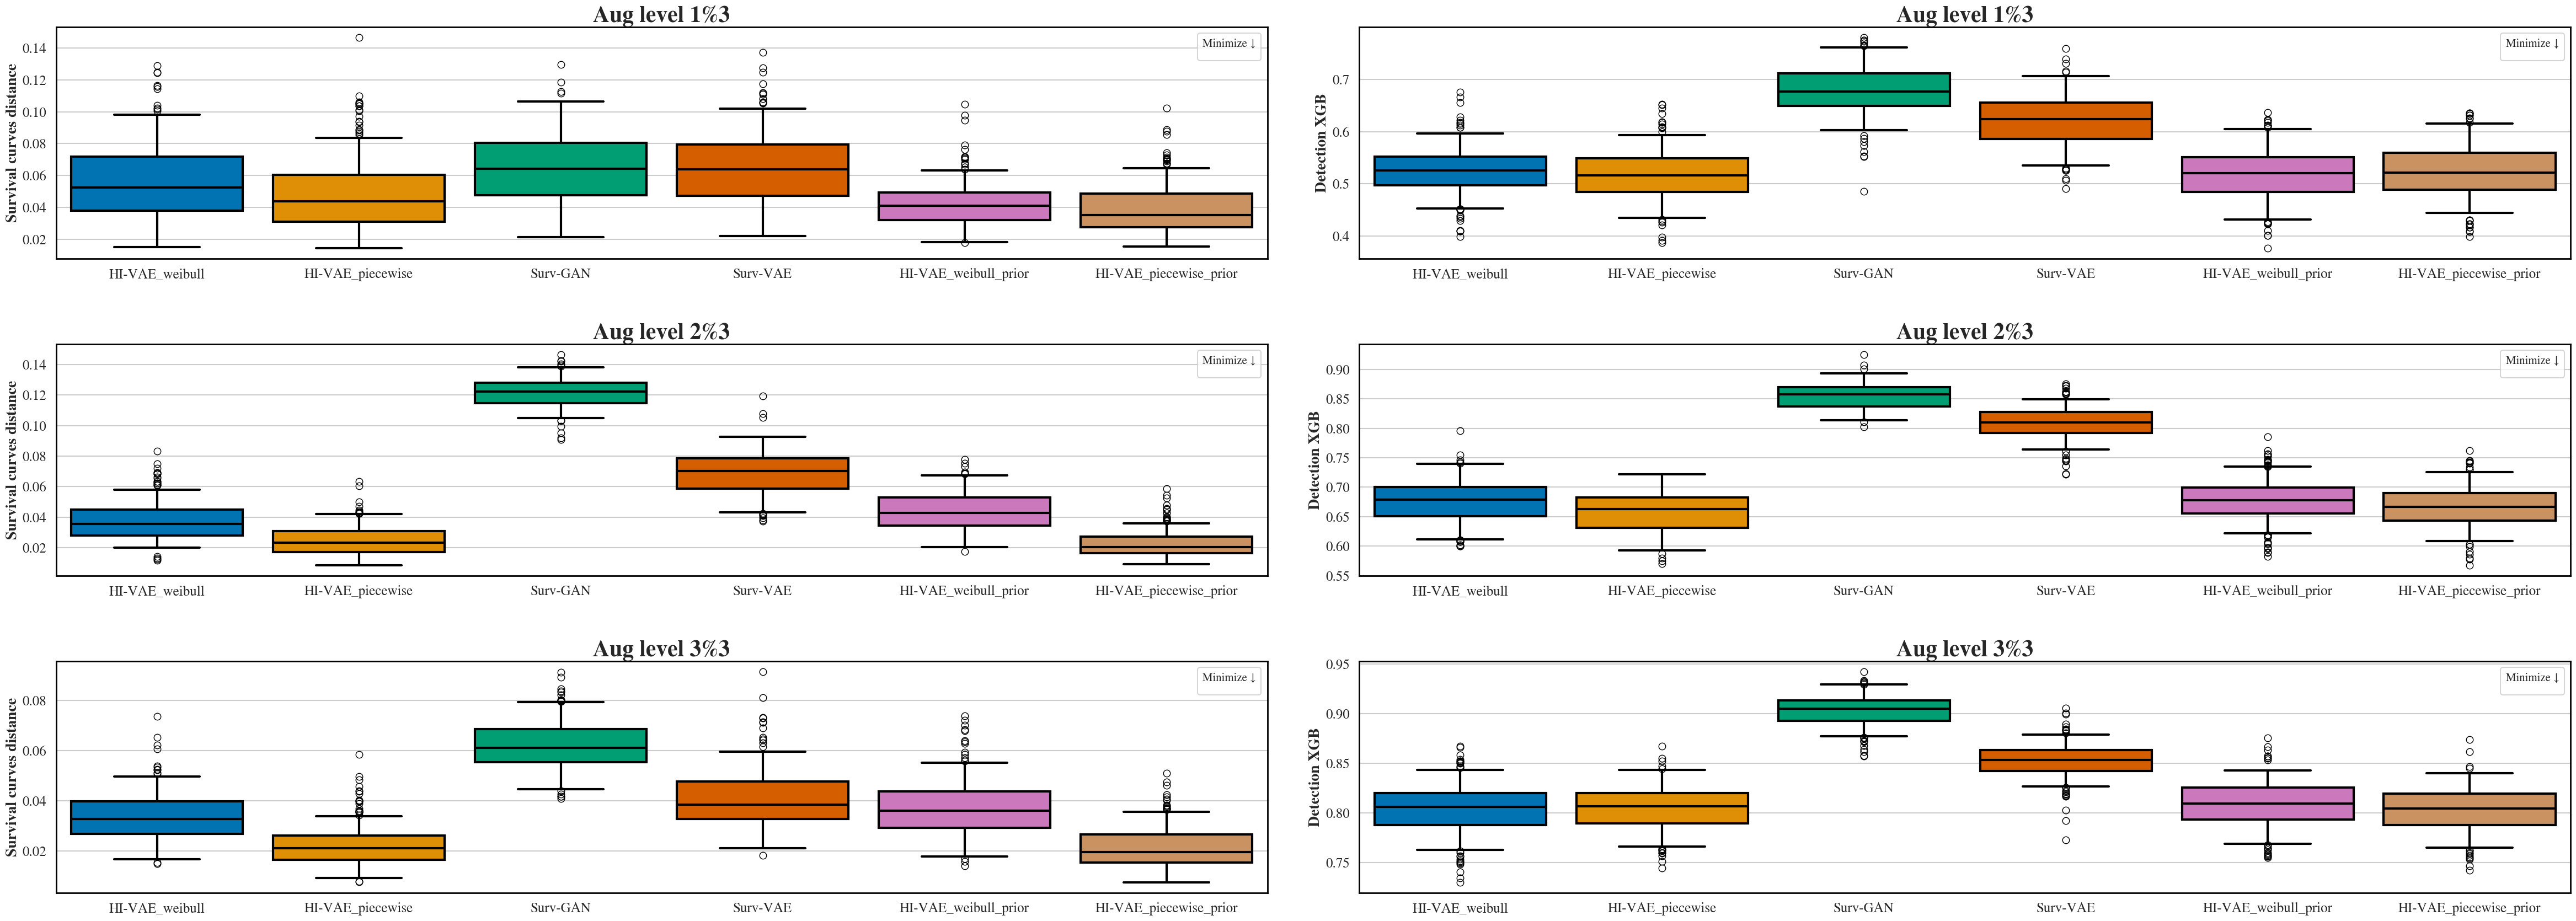

In [14]:
visualize("NCT00339183", generators_sel, metrics=[['Survival curves distance', "min"], ['Detection XGB', "min"]])

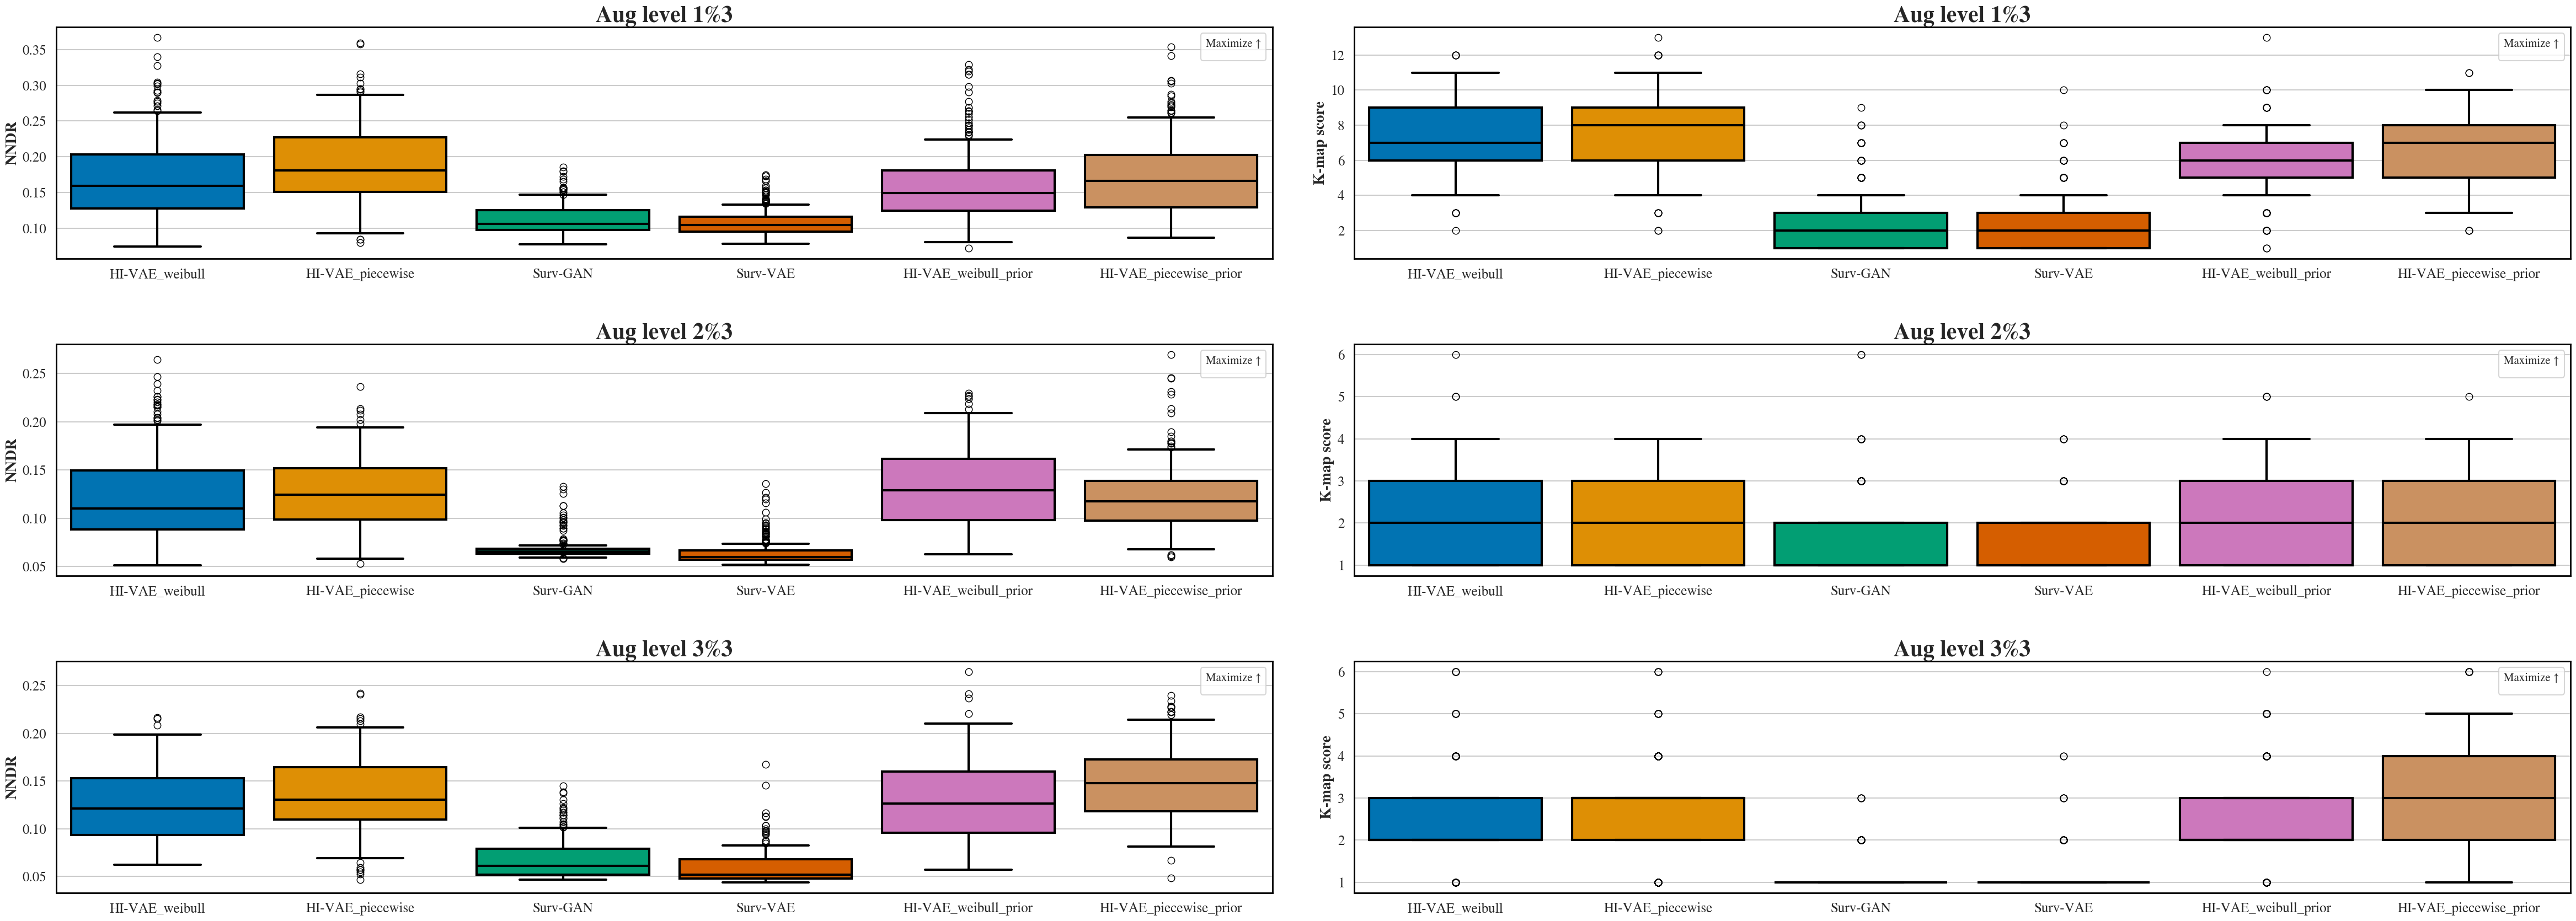

In [15]:
visualize("NCT00339183", generators_sel, metrics=[['NNDR', "max"], ['K-map score', "max"]])